Phase 2 — Exploratory Data Analysis

# Phase 2 — Exploratory Data Analysis

## Objective

The objective of Phase 2 is to explore the StreamFlix data and identify
important patterns, trends, distributions, and relationships.

The analysis will focus on viewing behaviour, watch hours, content performance,
subscriber characteristics, device usage, completion rates, and review
sentiment.

A total of 10 visualizations will be created to communicate the key findings
clearly.

Each visualization will be accompanied by 2–3 sentences of observation.

Import Visualization Libraries

In [12]:
import matplotlib.pyplot as plt
import numpy as np

Create a Folder for Charts

## 2.1 Chart Export Setup

All Phase 2 visualizations will be saved as PNG images in a dedicated
Phase2_Charts folder.

In [13]:
from pathlib import Path

project_path = Path(r"D:\StreamFlix Content Analytics Project")

print("Project Path:")
print(project_path)

Project Path:
D:\StreamFlix Content Analytics Project


In [14]:
charts_path = project_path / "Phase2_Charts"

charts_path.mkdir(exist_ok=True)

print("Chart folder created:")
print(charts_path)

Chart folder created:
D:\StreamFlix Content Analytics Project\Phase2_Charts


Load the Cleaned Data

In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_path = Path(r"D:\StreamFlix Content Analytics Project")

cleaned_path = project_path / "Cleaned_Data"
charts_path = project_path / "Phase2_Charts"

print("Cleaned data path:")
print(cleaned_path)

print("\nChart path:")
print(charts_path)

Cleaned data path:
D:\StreamFlix Content Analytics Project\Cleaned_Data

Chart path:
D:\StreamFlix Content Analytics Project\Phase2_Charts


In [19]:
subscribers = pd.read_csv(cleaned_path / "subscribers_clean.csv")
titles = pd.read_csv(cleaned_path / "titles_clean.csv")
watch_history = pd.read_csv(cleaned_path / "watch_history_clean.csv")
ratings = pd.read_csv(cleaned_path / "ratings_clean.csv")
reviews = pd.read_csv(cleaned_path / "reviews_clean.csv")
watchlist = pd.read_csv(cleaned_path / "watchlist_clean.csv")

print("All 6 cleaned datasets loaded successfully.")

All 6 cleaned datasets loaded successfully.


In [20]:
watch_history["watch_date"] = pd.to_datetime(
    watch_history["watch_date"]
)

print("watch_date data type:", watch_history["watch_date"].dtype)

watch_date data type: datetime64[ns]


In [21]:
print("Watch History Shape:", watch_history.shape)
print("Earliest Date:", watch_history["watch_date"].min())
print("Latest Date:", watch_history["watch_date"].max())

Watch History Shape: (650000, 10)
Earliest Date: 2017-03-10 00:00:00
Latest Date: 2026-05-31 00:00:00


Chart 1: Monthly Viewing Volume

## 2.2 Chart 1 — Monthly Viewing Volume

### Objective

To analyse the number of viewing sessions recorded each month and identify the
busiest months across the StreamFlix viewing timeline.

Each row in watch_history represents a viewing session, so watch_id will be
counted after grouping the data by month.

In [22]:
# Create monthly viewing volume

monthly_views = (
    watch_history
    .set_index("watch_date")
    .resample("MS")["watch_id"]
    .count()
    .reset_index(name="viewing_sessions")
)

monthly_views.head()

,watch_date,viewing_sessions
0,2017-03-01,1
1,2017-04-01,1
2,2017-05-01,1
3,2017-06-01,0
4,2017-07-01,1


In [23]:
print("Number of months:", len(monthly_views))

print("\nMonthly Viewing Volume:")
print(monthly_views)

Number of months: 111

Monthly Viewing Volume:
    watch_date  viewing_sessions
0   2017-03-01                 1
1   2017-04-01                 1
2   2017-05-01                 1
3   2017-06-01                 0
4   2017-07-01                 1
..         ...               ...
106 2026-01-01             27970
107 2026-02-01             33795
108 2026-03-01             55665
109 2026-04-01             90383
110 2026-05-01            224696

[111 rows x 2 columns]


### 2.2.1 Identify the Busiest Months

The monthly viewing data will be sorted by viewing sessions to identify the
months with the highest viewing activity.

In [24]:
# Identify the top 5 busiest months

busiest_months = (
    monthly_views
    .sort_values("viewing_sessions", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

busiest_months

,watch_date,viewing_sessions
0,2026-05-01,224696
1,2026-04-01,90383
2,2026-03-01,55665
3,2026-02-01,33795
4,2026-01-01,27970


In [25]:
# Identify the 5 months with the lowest viewing volume

lowest_months = (
    monthly_views
    .sort_values("viewing_sessions", ascending=True)
    .head(5)
    .reset_index(drop=True)
)

lowest_months

,watch_date,viewing_sessions
0,2017-06-01,0
1,2017-08-01,0
2,2017-03-01,1
3,2017-04-01,1
4,2017-05-01,1


### 2.2.2 Monthly Viewing Volume Visualization

A line chart is used to show the change in viewing sessions over time.

The five busiest months are highlighted to make the periods with the highest
viewing activity easy to identify.

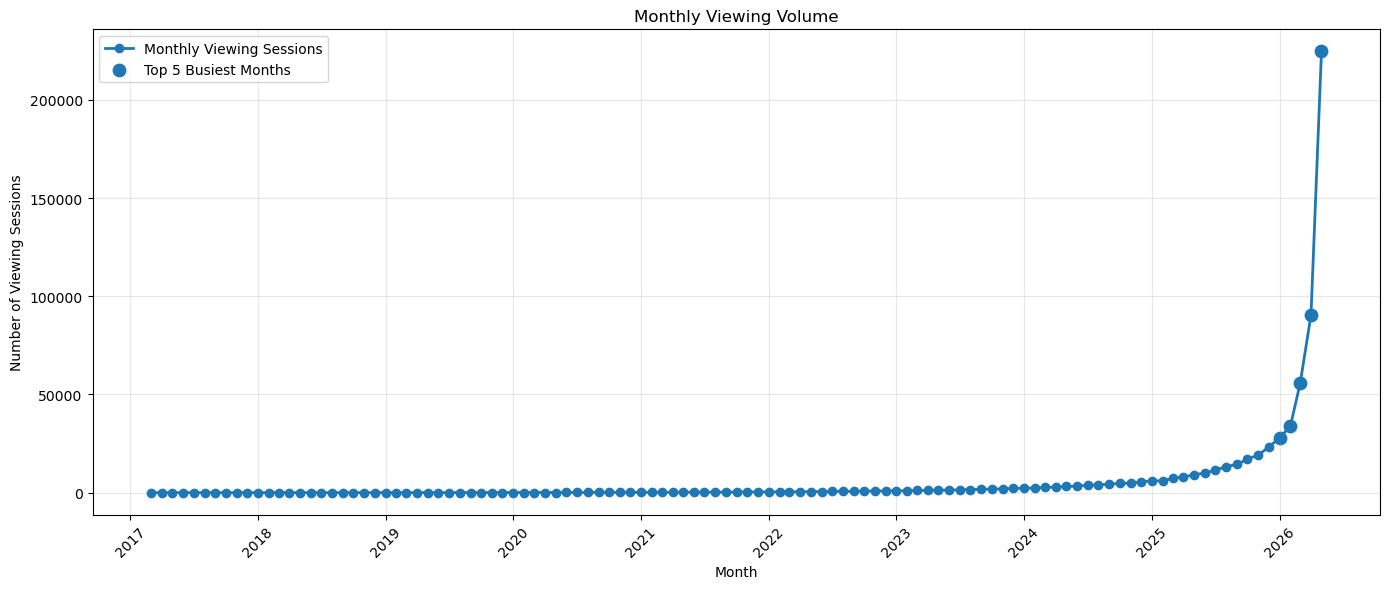

In [26]:
# Create Monthly Viewing Volume Chart

plt.figure(figsize=(14, 6))

# Main monthly trend
plt.plot(
    monthly_views["watch_date"],
    monthly_views["viewing_sessions"],
    marker="o",
    linewidth=2,
    label="Monthly Viewing Sessions"
)

# Highlight top 5 busiest months
plt.scatter(
    busiest_months["watch_date"],
    busiest_months["viewing_sessions"],
    s=80,
    label="Top 5 Busiest Months"
)

plt.title("Monthly Viewing Volume")
plt.xlabel("Month")
plt.ylabel("Number of Viewing Sessions")

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "01_Monthly_Viewing_Volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Monthly viewing activity increased substantially toward the later part of the
timeline. The highest viewing volume occurred in May 2026 with 224,696
sessions, followed by April 2026 with 90,383 sessions.

The early part of the timeline recorded very low viewing activity, including
months with zero sessions. The sharp increase during 2026 indicates that
viewing activity was concentrated heavily in the most recent months of the
dataset.

## 2.3 Chart 2 — Monthly Watch Hours Trend

### Objective

To analyse the monthly trend in total watch hours and understand how viewing
time changed across the timeline.

The watch_duration_min field will be converted from minutes to hours and
aggregated by month. Year-over-year patterns will also be examined.

In [27]:
# Convert watch duration from minutes to hours

watch_history["watch_hours"] = (
    watch_history["watch_duration_min"] / 60
)

# Calculate total watch hours by month

monthly_watch_hours = (
    watch_history
    .set_index("watch_date")
    .resample("MS")["watch_hours"]
    .sum()
    .reset_index()
)

monthly_watch_hours.head()

,watch_date,watch_hours
0,2017-03-01,4.773333
1,2017-04-01,4.400000
2,2017-05-01,14.416667
3,2017-06-01,0.000000
4,2017-07-01,1.413333


### 2.3.1 Identify the Highest Watch-Hours Months

The monthly watch-hours data will be sorted to identify the months with the
highest total viewing time.

These months will be highlighted in the final visualization.

In [28]:
# Identify the top 5 months by total watch hours

highest_watch_hours = (
    monthly_watch_hours
    .sort_values("watch_hours", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

highest_watch_hours

,watch_date,watch_hours
0,2026-05-01,1.157786e+06
1,2026-04-01,4.633373e+05
2,2026-03-01,2.860884e+05
3,2026-02-01,1.745655e+05
4,2026-01-01,1.435220e+05


In [29]:
# Calculate total watch hours by year

yearly_watch_hours = (
    watch_history
    .set_index("watch_date")
    .resample("YS")["watch_hours"]
    .sum()
    .reset_index()
)

yearly_watch_hours["year"] = (
    yearly_watch_hours["watch_date"].dt.year
)

yearly_watch_hours

,watch_date,watch_hours,year
0,2017-01-01,4.575667e+01,2017
1,2018-01-01,5.835400e+02,2018
2,2019-01-01,1.679413e+03,2019
3,2020-01-01,5.471778e+03,2020
4,2021-01-01,1.543533e+04,2021
5,2022-01-01,3.735396e+04,2022
6,2023-01-01,8.966582e+04,2023
7,2024-01-01,2.239940e+05,2024
8,2025-01-01,7.339391e+05,2025
9,2026-01-01,2.225299e+06,2026


### 2.3.2 Monthly Watch Hours Visualization

A line chart is used to show the monthly trend in total watch hours across the
timeline.

The five months with the highest watch hours are highlighted to identify the
periods with the greatest viewing time.

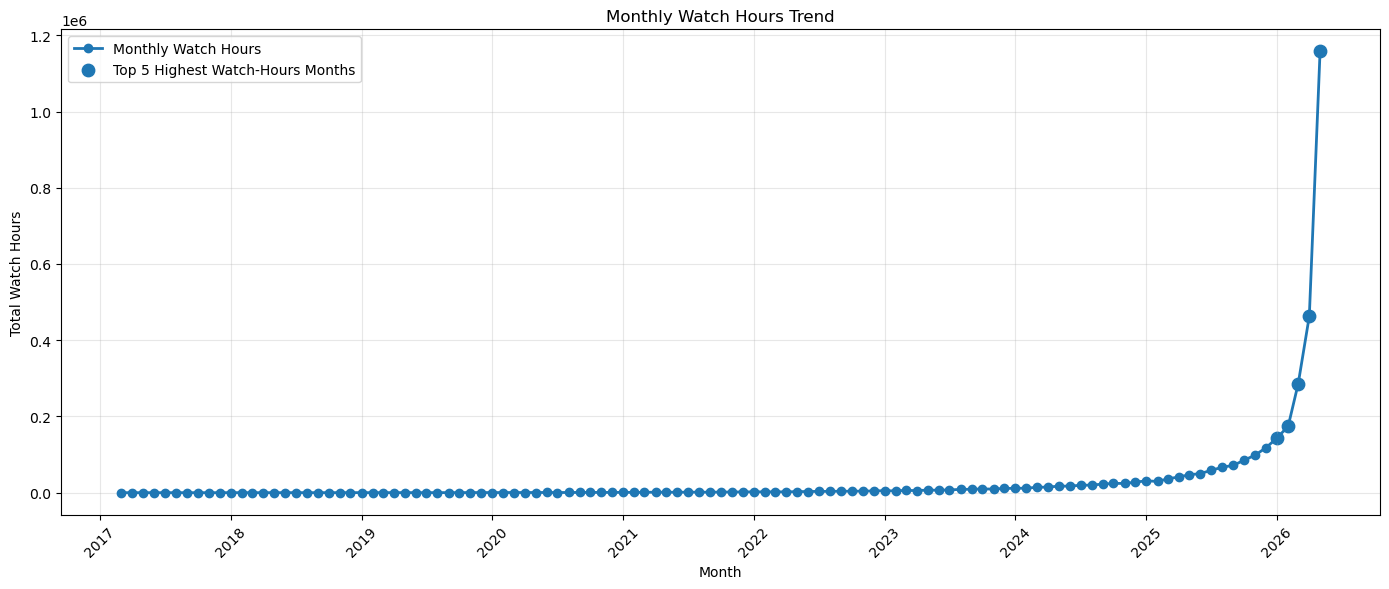

In [30]:
# Create Monthly Watch Hours Chart

plt.figure(figsize=(14, 6))

# Main monthly trend
plt.plot(
    monthly_watch_hours["watch_date"],
    monthly_watch_hours["watch_hours"],
    marker="o",
    linewidth=2,
    label="Monthly Watch Hours"
)

# Highlight top 5 months
plt.scatter(
    highest_watch_hours["watch_date"],
    highest_watch_hours["watch_hours"],
    s=80,
    label="Top 5 Highest Watch-Hours Months"
)

plt.title("Monthly Watch Hours Trend")
plt.xlabel("Month")
plt.ylabel("Total Watch Hours")

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "02_Monthly_Watch_Hours_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Total watch hours increased consistently across the years, rising from
approximately 45.76 hours in 2017 to 733,939.10 hours in 2025. The total for
2026 is already 2,225,299.00 hours, although 2026 contains data only through
May.

At the monthly level, May 2026 recorded the highest watch time at
1,157,786.00 hours, followed by April 2026 with 463,333.33 hours. The sharp
increase in recent months indicates substantially higher viewing activity
toward the end of the available timeline.

## 2.4 Chart 3 — Genre-Wise Watch Hours Share

### Objective

To analyse how total watch time is distributed across content genres.

The watch history data will be joined with the titles table using title_id.
Watch duration will then be aggregated by primary_genre to identify the
genres receiving the highest total watch time.

In [31]:
# Convert watch history into genre-level watch hours

genre_watch_hours = (
    watch_history
    .merge(
        titles[["title_id", "primary_genre"]],
        on="title_id",
        how="left"
    )
    .groupby("primary_genre", as_index=False)["watch_hours"]
    .sum()
    .sort_values("watch_hours", ascending=False)
)

genre_watch_hours

,primary_genre,watch_hours
5,Drama,501884.466667
2,Comedy,423149.053333
0,Action,393171.916667
15,Thriller,307024.663333
4,Documentary,291216.898333
3,Crime,237435.838333
12,Romance,214332.301667
1,Animation,180093.938333
13,Sci-Fi,154332.208333
7,Horror,138033.605000


### 2.4.1 Genre-Wise Watch Hours Visualization

A horizontal bar chart is used to compare total watch hours across content
genres.

The genres are ordered from highest to lowest watch hours so that the genre
with the greatest viewing time can be easily identified.

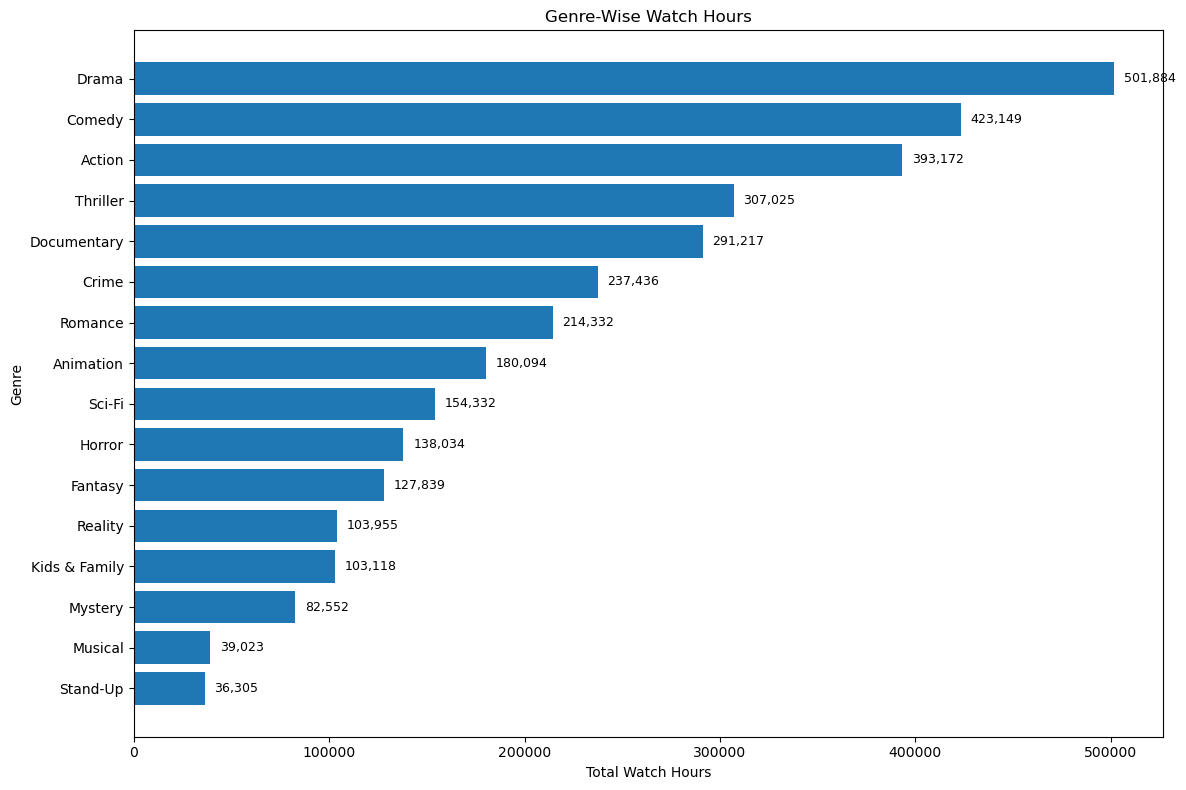

In [33]:
# Create Genre-Wise Watch Hours Chart with Data Labels

genre_chart = genre_watch_hours.sort_values(
    "watch_hours",
    ascending=True
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    genre_chart["primary_genre"],
    genre_chart["watch_hours"]
)

plt.title("Genre-Wise Watch Hours")
plt.xlabel("Total Watch Hours")
plt.ylabel("Genre")

# Add data labels
for bar in bars:
    value = bar.get_width()
    
    plt.text(
        value + 5000,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "03_Genre_Wise_Watch_Hours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Drama recorded the highest total watch time at approximately 501,884.47 hours,
followed by Comedy at 423,149.05 hours and Action at 393,171.92 hours.

Thriller and Documentary also recorded substantial viewing time, while Musical
and Stand-Up had the lowest total watch hours among the listed genres.

## 2.5 Chart 4 — Content Type Split

### Objective

To compare total watch hours between Movies and TV Shows and understand how
viewing time is distributed across the two content types.

In [34]:
# Calculate watch hours by content type

content_type_watch_hours = (
    watch_history
    .merge(
        titles[["title_id", "type"]],
        on="title_id",
        how="left"
    )
    .groupby("type", as_index=False)["watch_hours"]
    .sum()
    .sort_values("watch_hours", ascending=False)
)

content_type_watch_hours

,type,watch_hours
1,TV Show,2.882609e+06
0,Movie,4.508588e+05


### 2.5.1 Content Type Watch-Hours Visualization

A donut chart is used to show the share of total watch hours between Movies
and TV Shows.

In [35]:
# Calculate content type percentage share

content_type_watch_hours["watch_hours_share_pct"] = (
    content_type_watch_hours["watch_hours"]
    / content_type_watch_hours["watch_hours"].sum()
    * 100
)

content_type_watch_hours

,type,watch_hours,watch_hours_share_pct
1,TV Show,2.882609e+06,86.474781
0,Movie,4.508588e+05,13.525219


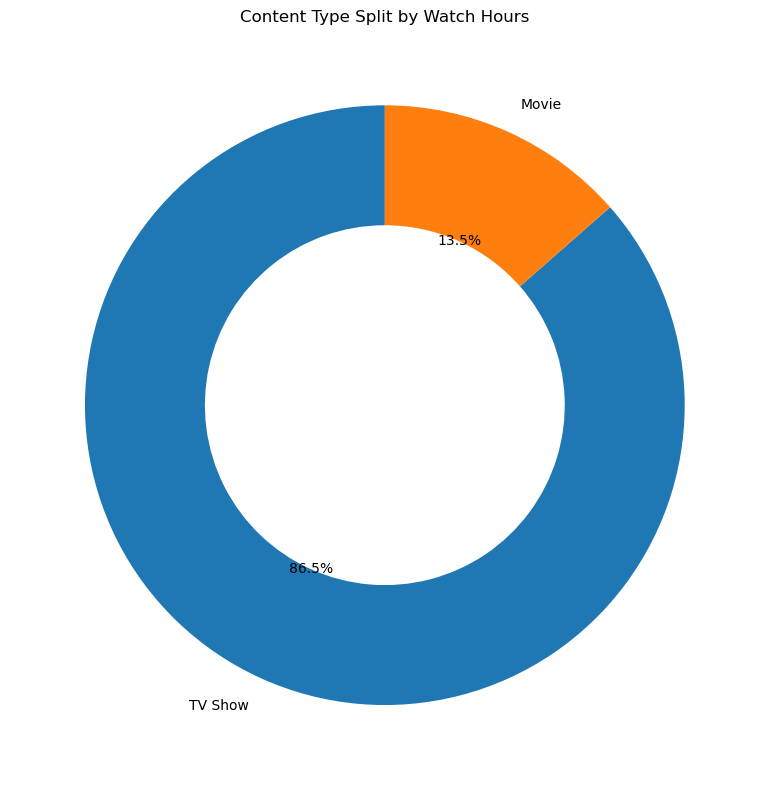

In [36]:
# Create Content Type Split Donut Chart

plt.figure(figsize=(8, 8))

plt.pie(
    content_type_watch_hours["watch_hours"],
    labels=content_type_watch_hours["type"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Content Type Split by Watch Hours")

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "04_Content_Type_Split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

TV Shows accounted for approximately 86.48% of total watch hours, while Movies
accounted for approximately 13.52%.

This indicates that the majority of viewing time in the dataset was spent
watching TV Shows rather than Movies.

## 2.6 Chart 5 — Top 10 Countries by Watch Hours

### Objective

To identify the top 10 countries by total watch hours and compare viewing
activity across countries.

Watch duration will be converted to hours and aggregated by region.

In [37]:
# Calculate total watch hours by country/region

country_watch_hours = (
    watch_history
    .groupby("region", as_index=False)["watch_hours"]
    .sum()
    .sort_values("watch_hours", ascending=False)
)

country_watch_hours

,region,watch_hours
5,North America,1.013484e+06
2,Europe,8.211636e+05
1,East Asia,4.112069e+05
3,Latin America,3.976540e+05
7,South Asia,3.809177e+05
4,Middle East,1.116150e+05
8,Southeast Asia,7.681218e+04
0,Africa,6.097477e+04
6,Oceania,5.963973e+04


In [38]:
# Select the top 10 countries by watch hours

top_10_countries = (
    country_watch_hours
    .head(10)
    .reset_index(drop=True)
)

top_10_countries

,region,watch_hours
0,North America,1.013484e+06
1,Europe,8.211636e+05
2,East Asia,4.112069e+05
3,Latin America,3.976540e+05
4,South Asia,3.809177e+05
5,Middle East,1.116150e+05
6,Southeast Asia,7.681218e+04
7,Africa,6.097477e+04
8,Oceania,5.963973e+04


### 2.6.1 Calculate Watch Hours by Country

The watch_history table contains viewer region information, while the
subscribers table contains the subscriber's country.

To meet the project requirement, watch_history will be joined with subscribers
using subscriber_id. Total watch hours will then be aggregated by country.

In [39]:
# Calculate total watch hours by country

country_watch_hours = (
    watch_history
    .merge(
        subscribers[["subscriber_id", "country"]],
        on="subscriber_id",
        how="left"
    )
    .groupby("country", as_index=False)["watch_hours"]
    .sum()
    .sort_values("watch_hours", ascending=False)
)

country_watch_hours

,country,watch_hours
19,United States,910551.198333
7,India,380917.681667
18,United Kingdom,285346.350000
13,South Korea,239498.930000
2,Brazil,206648.200000
10,Japan,171707.983333
5,France,167418.188333
11,Mexico,143971.786667
14,Spain,137107.413333
6,Germany,136936.378333


In [40]:
# Select the top 10 countries by watch hours

top_10_countries = (
    country_watch_hours
    .head(10)
    .reset_index(drop=True)
)

top_10_countries

,country,watch_hours
0,United States,910551.198333
1,India,380917.681667
2,United Kingdom,285346.350000
3,South Korea,239498.930000
4,Brazil,206648.200000
5,Japan,171707.983333
6,France,167418.188333
7,Mexico,143971.786667
8,Spain,137107.413333
9,Germany,136936.378333


### 2.6.2 Top 10 Countries by Watch Hours Visualization

A horizontal bar chart is used to compare total watch hours across the top 10
countries.

Data labels are included to show the exact watch-hour values for each country.

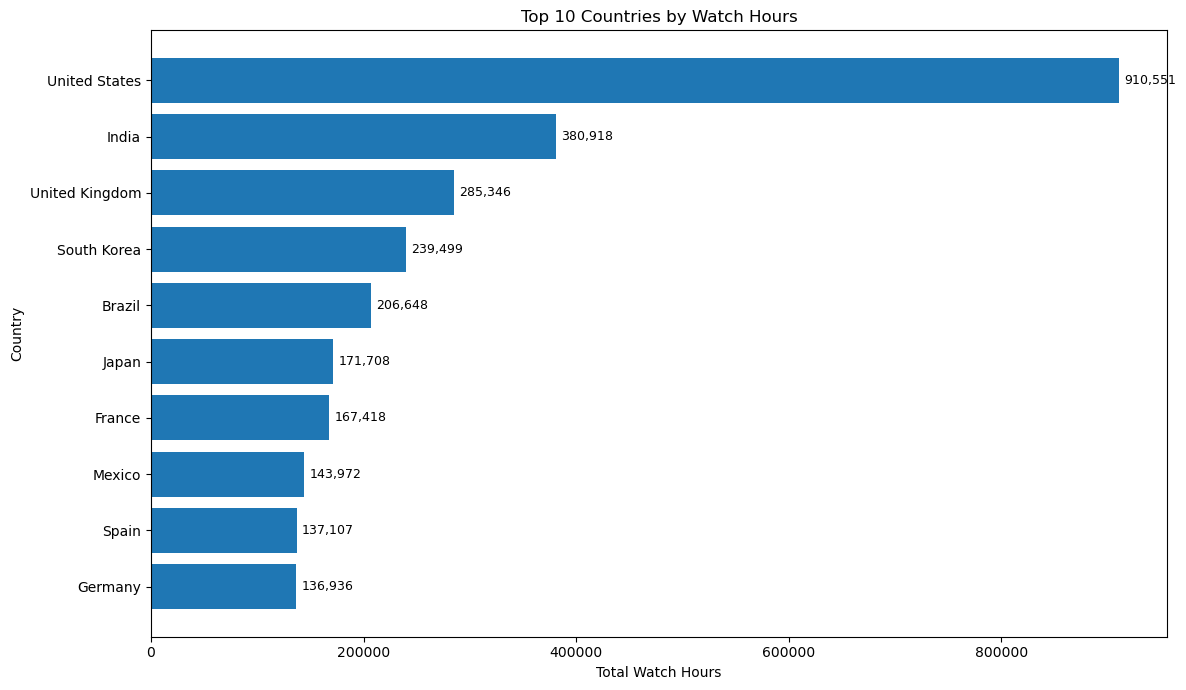

In [41]:
# Create Top 10 Countries by Watch Hours Chart

country_chart = top_10_countries.sort_values(
    "watch_hours",
    ascending=True
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    country_chart["country"],
    country_chart["watch_hours"]
)

plt.title("Top 10 Countries by Watch Hours")
plt.xlabel("Total Watch Hours")
plt.ylabel("Country")

# Add data labels
for bar in bars:
    value = bar.get_width()
    
    plt.text(
        value + 5000,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "05_Top_10_Countries_Watch_Hours.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
print("Chart saved successfully:")
print(charts_path / "05_Top_10_Countries_Watch_Hours.png")

Chart saved successfully:
D:\StreamFlix Content Analytics Project\Phase2_Charts\05_Top_10_Countries_Watch_Hours.png


### Observation

The United States recorded the highest total watch hours at approximately
910,551 hours, followed by India with approximately 380,918 hours.

The United Kingdom, South Korea, and Brazil also recorded substantial viewing
activity, while Germany had the lowest watch hours among the top 10 countries.

Overall, the chart shows that viewing activity is concentrated among a small
number of major markets.

## 2.7 Chart 6 — Subscriber Plan Distribution

### Objective

To understand the distribution of subscribers across the available subscription
plans: Basic, Standard, and Premium.

The analysis will calculate the number and percentage of subscribers in each
plan category.

In [45]:
# Calculate subscriber plan distribution

plan_distribution = (
    subscribers["plan_type"]
    .value_counts()
    .reset_index()
)

plan_distribution.columns = ["plan_type", "subscriber_count"]

plan_distribution

,plan_type,subscriber_count
0,Standard,6100
1,Basic with Ads,4458
2,Premium,4442


### 2.7.1 Subscriber Plan Distribution Visualization

A pie chart is used to show the proportion of subscribers across the three
subscription plans.

The chart includes both subscriber counts and percentage labels to make the
distribution easy to interpret.

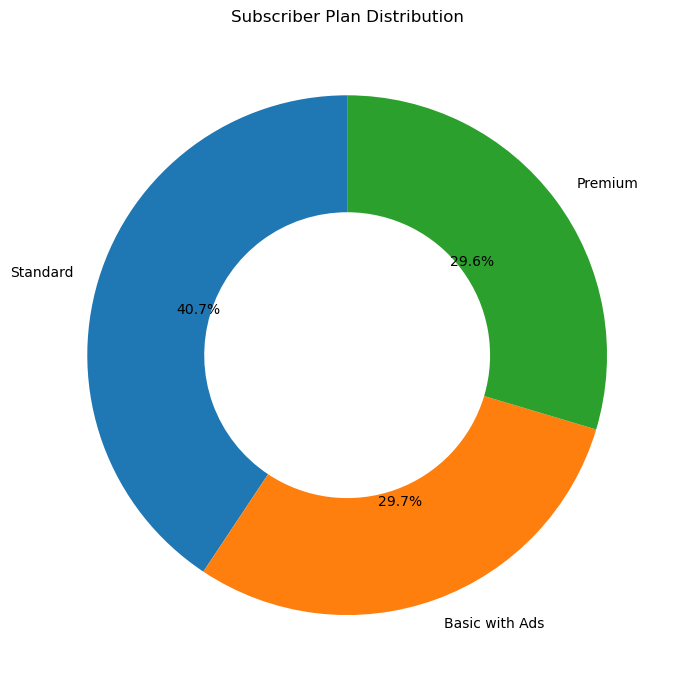

In [46]:
# Create Subscriber Plan Distribution Pie Chart

plt.figure(figsize=(9, 7))

plt.pie(
    plan_distribution["subscriber_count"],
    labels=plan_distribution["plan_type"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45}
)

plt.title("Subscriber Plan Distribution")

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "06_Subscriber_Plan_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The Standard plan has the largest subscriber base with 6,100 subscribers,
followed by Basic with Ads with 4,458 subscribers and Premium with 4,442
subscribers.

The distribution indicates that the Standard plan accounts for the largest
share of the subscriber base, while Basic with Ads and Premium have relatively
similar subscriber counts.

## 2.8 Chart 7 — Device Usage

### Objective

To understand which devices are most commonly used by subscribers to watch
content on the platform.

The analysis will count viewing sessions by device type and compare the
distribution using a bar chart.

In [47]:
# Calculate viewing sessions by device

device_usage = (
    watch_history["device"]
    .value_counts()
    .reset_index()
)

device_usage.columns = ["device", "viewing_sessions"]

device_usage

,device,viewing_sessions
0,Smart TV,221446
1,Mobile,175605
2,Laptop,96408
3,Tablet,65276
4,Game Console,52322
5,Streaming Stick,38943


### 2.8.1 Device Usage Visualization

A horizontal bar chart is used to compare viewing sessions across different
device types.

Data labels are included to display the exact number of viewing sessions for
each device.

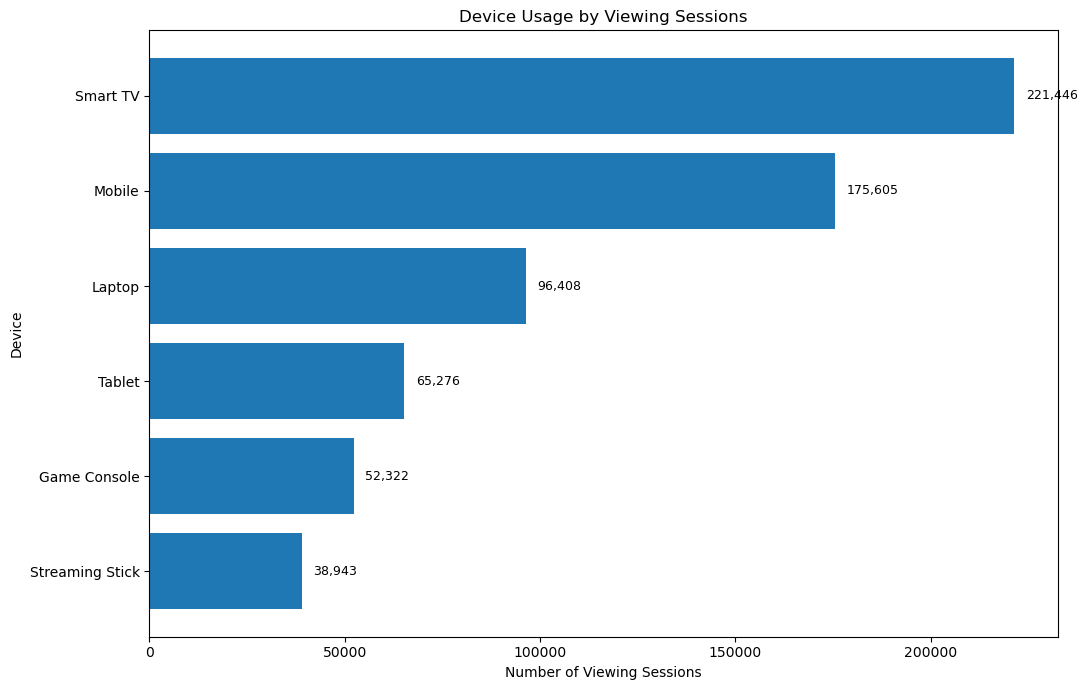

In [48]:
# Create Device Usage Bar Chart

device_chart = device_usage.sort_values(
    "viewing_sessions",
    ascending=True
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    device_chart["device"],
    device_chart["viewing_sessions"]
)

plt.title("Device Usage by Viewing Sessions")
plt.xlabel("Number of Viewing Sessions")
plt.ylabel("Device")

# Add data labels
for bar in bars:
    value = bar.get_width()
    
    plt.text(
        value + 3000,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "07_Device_Usage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Smart TV recorded the highest number of viewing sessions at 221,446,
followed by Mobile with 175,605 sessions.

Laptop, Tablet, Game Console, and Streaming Stick recorded progressively
lower viewing session volumes.

Overall, Smart TV and Mobile together account for a substantial portion of
the recorded viewing sessions.

## 2.9 Chart 8 — Age Distribution of Subscribers

### Objective

To understand the age distribution of subscribers and identify the age groups
with the highest representation in the subscriber base.

A histogram will be used to visualize the distribution of subscriber ages.

In [49]:
# Check subscriber age distribution

age_summary = subscribers["age"].describe()

age_summary

count    15000.000000
mean        35.620267
std         12.532555
min         13.000000
25%         27.000000
50%         35.000000
75%         44.000000
max         85.000000
Name: age, dtype: float64

In [50]:
# Check minimum and maximum age

print("Minimum age:", subscribers["age"].min())
print("Maximum age:", subscribers["age"].max())
print("Missing ages:", subscribers["age"].isna().sum())

Minimum age: 13
Maximum age: 85
Missing ages: 0


Identify the Most Represented Age Group

In [51]:
# Create age groups

age_bins = [0, 17, 24, 34, 44, 54, 64, 74, 100]
age_labels = [
    "Under 18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65-74",
    "75+"
]

age_groups = pd.cut(
    subscribers["age"],
    bins=age_bins,
    labels=age_labels,
    right=True
)

age_group_counts = (
    age_groups
    .value_counts()
    .sort_index()
    .reset_index()
)

age_group_counts.columns = ["age_group", "subscriber_count"]

age_group_counts

,age_group,subscriber_count
0,Under 18,1270
1,18-24,1715
2,25-34,4094
3,35-44,4291
4,45-54,2557
5,55-64,892
6,65-74,165
7,75+,16


### 2.9.1 Age Distribution Visualization

A histogram is used to visualize the distribution of subscriber ages.

The chart helps identify the concentration of subscribers across different age
ranges.

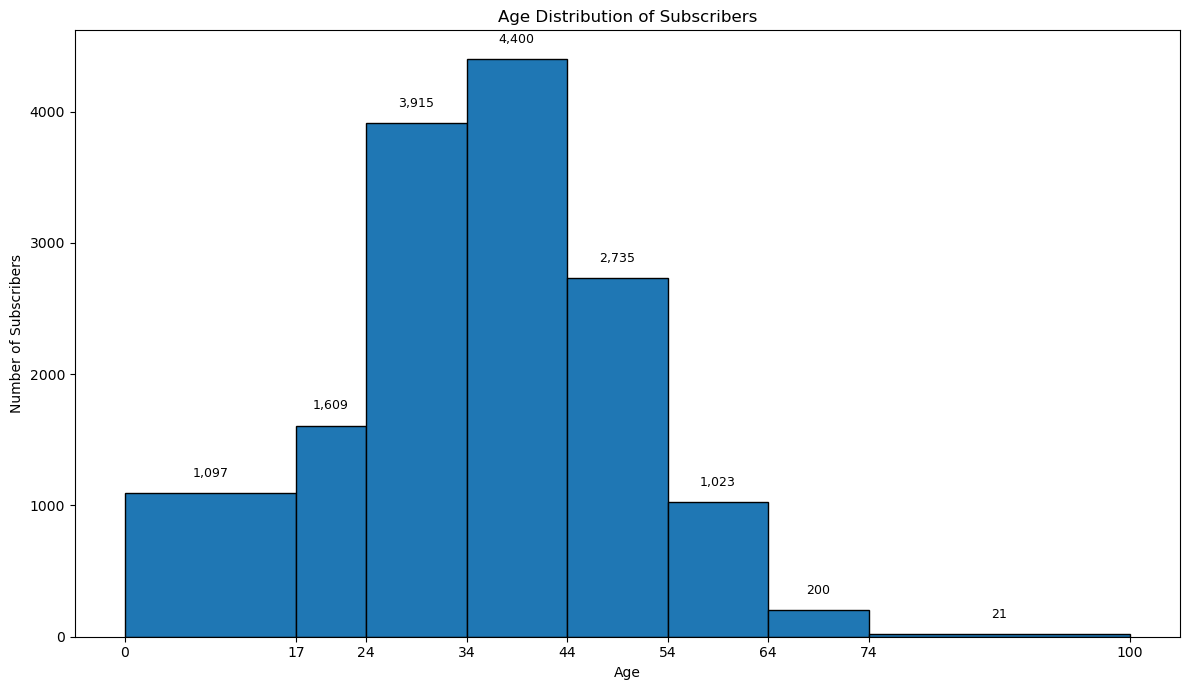

In [53]:
# Create Age Distribution Histogram with Data Labels

plt.figure(figsize=(12, 7))

# Create histogram
counts, bins, patches = plt.hist(
    subscribers["age"],
    bins=age_bins,
    edgecolor="black"
)

plt.title("Age Distribution of Subscribers")
plt.xlabel("Age")
plt.ylabel("Number of Subscribers")

# Add data labels above each bar
for count, left, right in zip(counts, bins[:-1], bins[1:]):
    if count > 0:
        plt.text(
            (left + right) / 2,
            count + 100,
            f"{int(count):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Show age ranges clearly
plt.xticks(
    bins,
    [str(int(x)) for x in bins]
)

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "08_Age_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The age distribution shows that subscribers are concentrated mainly in the
25–54 age range.

- The 35–44 age group has the highest representation, with approximately
  4,400 subscribers.
- The 25–34 age group follows with approximately 3,915 subscribers.
- The 45–54 age group has approximately 2,735 subscribers.
- Subscriber counts decline noticeably after age 54.
- The 75+ age group has the smallest representation, with only 21 subscribers.

Overall, the subscriber base is primarily concentrated between ages 25 and 54,
with the 35–44 age group forming the largest age segment.

## 2.10 Chart 9 — Completion Rate by Genre

### Objective

To compare the average content completion percentage across different genres
and identify which genres have the highest and lowest completion rates.

The average `completion_pct` from watch_history will be grouped by
`primary_genre` from titles using `title_id`.

In [54]:
# Calculate completion rate by genre

genre_completion = (
    watch_history
    .merge(
        titles[["title_id", "primary_genre"]],
        on="title_id",
        how="left"
    )
    .groupby("primary_genre", as_index=False)["completion_pct"]
    .mean()
    .sort_values("completion_pct", ascending=False)
)

genre_completion.columns = [
    "primary_genre",
    "avg_completion_pct"
]

genre_completion

,primary_genre,avg_completion_pct
9,Musical,66.834788
1,Animation,66.383549
14,Stand-Up,66.319730
6,Fantasy,65.968073
13,Sci-Fi,65.793368
10,Mystery,65.558980
3,Crime,65.461294
2,Comedy,65.316334
8,Kids & Family,65.309259
15,Thriller,65.307925


In [55]:
# Display completion rates with two decimal places

genre_completion["avg_completion_pct"] = (
    genre_completion["avg_completion_pct"].round(2)
)

genre_completion

,primary_genre,avg_completion_pct
9,Musical,66.83
1,Animation,66.38
14,Stand-Up,66.32
6,Fantasy,65.97
13,Sci-Fi,65.79
10,Mystery,65.56
3,Crime,65.46
2,Comedy,65.32
8,Kids & Family,65.31
15,Thriller,65.31


### 2.10.1 Completion Rate by Genre Visualization

A horizontal bar chart is used to compare the average completion percentage
across genres.

Data labels are included to display the exact average completion rate for
each genre.

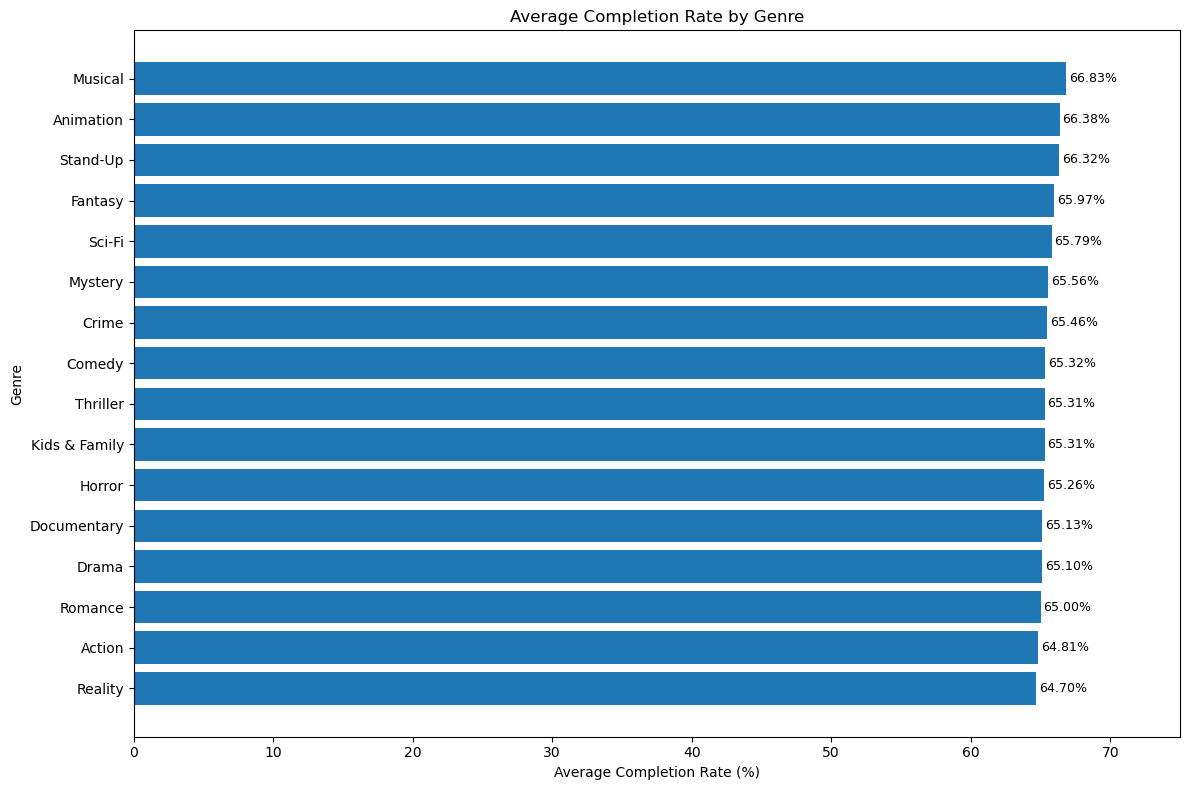

In [56]:
# Create Completion Rate by Genre Chart

genre_chart = genre_completion.sort_values(
    "avg_completion_pct",
    ascending=True
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    genre_chart["primary_genre"],
    genre_chart["avg_completion_pct"]
)

plt.title("Average Completion Rate by Genre")
plt.xlabel("Average Completion Rate (%)")
plt.ylabel("Genre")

# Add data labels
for bar in bars:
    value = bar.get_width()

    plt.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=9
    )

plt.xlim(0, 75)

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "09_Completion_Rate_by_Genre.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Musical has the highest average completion rate at 66.83%, followed by
Animation at 66.38% and Stand-Up at 66.32%.

Reality has the lowest average completion rate at 64.70%, followed by Action
at 64.81%.

The completion rates across genres are relatively close, ranging from 64.70%
to 66.83%, indicating limited variation in average completion behavior across
genres.

## 2.11 Chart 10 — Review Sentiment Breakdown

### Objective

To understand the overall sentiment of subscriber reviews by comparing the
number of Positive, Neutral, and Negative reviews.

The analysis will count reviews within each sentiment category and visualize
the distribution using a bar chart.

In [57]:
# Calculate review sentiment distribution

sentiment_distribution = (
    reviews["sentiment"]
    .value_counts()
    .reindex(["Positive", "Neutral", "Negative"])
    .reset_index()
)

sentiment_distribution.columns = [
    "sentiment",
    "review_count"
]

sentiment_distribution

,sentiment,review_count
0,Positive,75007
1,Neutral,22759
2,Negative,12234


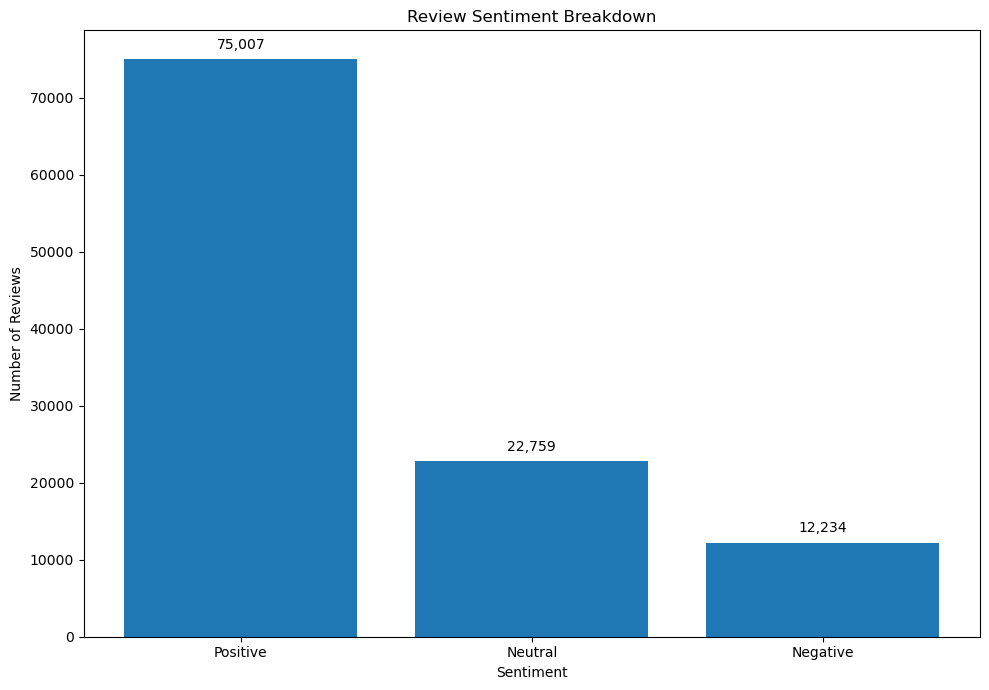

In [58]:
# Create Review Sentiment Breakdown Chart

plt.figure(figsize=(10, 7))

bars = plt.bar(
    sentiment_distribution["sentiment"],
    sentiment_distribution["review_count"]
)

plt.title("Review Sentiment Breakdown")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Add data labels
for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1000,
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "10_Review_Sentiment_Breakdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Positive reviews represent the largest sentiment category, with 75,007
reviews, followed by Neutral reviews with 22,759 and Negative reviews with
12,234.

The distribution shows that Positive reviews account for the majority of
recorded reviews, while Negative reviews represent the smallest category.

Overall, the review dataset contains substantially more Positive reviews than
Neutral or Negative reviews.

# Phase 2 — EDA Summary

## Key Findings

### 1. Monthly Viewing Volume

Viewing activity increased substantially over the later periods in the dataset,
with May 2026 recording the highest monthly viewing volume.

### 2. Monthly Watch Hours

Total watch hours followed a strong upward pattern over time, with the highest
monthly watch-hour volume recorded in May 2026.

### 3. Genre-Wise Watch Hours

Drama generated the highest total watch hours at approximately 501,884 hours,
followed by Comedy at approximately 423,149 hours and Action at approximately
393,172 hours.

### 4. Content Type Split

TV Shows accounted for approximately 86.5% of total watch hours, while Movies
accounted for approximately 13.5%.

### 5. Top 10 Countries by Watch Hours

The United States recorded the highest watch hours among the top 10 countries,
followed by India and the United Kingdom.

### 6. Subscriber Plan Distribution

Standard had the largest subscriber base with 6,100 subscribers, followed by
Basic with Ads with 4,458 subscribers and Premium with 4,442 subscribers.

### 7. Device Usage

Smart TV recorded the highest number of viewing sessions with 221,446 sessions,
followed by Mobile with 175,605 sessions.

### 8. Age Distribution

Subscribers were concentrated mainly in the 25–54 age range. The 35–44 age
group had the highest representation.

### 9. Completion Rate by Genre

Average completion rates were relatively close across genres, ranging from
64.70% to 66.83%. Musical recorded the highest average completion rate at
66.83%.

### 10. Review Sentiment

Positive reviews formed the largest sentiment category, with 75,007 reviews,
followed by Neutral with 22,759 and Negative with 12,234.

## Overall Conclusion

The EDA identified clear patterns in viewing activity, content preferences,
subscriber characteristics, device usage, geographic distribution, completion
behavior, and review sentiment.

The findings from Phase 2 provide a foundation for deeper KPI analysis and
business-focused insights in the next phase of the StreamFlix Content Analytics
Project.